In [2]:
import json
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

# Step 1: Load the JSON data
with open('normaltraffic.json', 'r', encoding='utf-8') as f:
  data = json.load(f)
print(f"Loaded {len(data)} packets from /content/normaltraffic.json")

Loaded 5796 packets from /content/normaltraffic.json


In [3]:
import pandas as pd

rows = []

for packet in data:

    layers = packet["_source"]["layers"]

    frame = layers.get("frame", {})
    ip = layers.get("ip", {})
    tcp = layers.get("tcp", {})

    rows.append({

        "time": pd.to_datetime(frame.get("frame.time_epoch")),

        "pkt_len": int(frame.get("frame.len", 0)),

        "src_ip": ip.get("ip.src", "0.0.0.0"),
        "dst_ip": ip.get("ip.dst", "0.0.0.0"),

        "ttl": int(ip.get("ip.ttl", 0)),

        "src_port": int(tcp.get("tcp.srcport", 0)),
        "dst_port": int(tcp.get("tcp.dstport", 0)),

        "tcp_len": int(tcp.get("tcp.len", 0)),

        "window": int(tcp.get("tcp.window_size", 0)),

        "time_delta": float(
            tcp.get("Timestamps", {}).get("tcp.time_delta", 0)
        )

    })

df = pd.DataFrame(rows)

In [4]:
# Add small epsilon to time_delta to avoid division by zero
df["pkt_rate"] = 1 / (df["time_delta"] + 1e-6)
df["flow"] = df["src_ip"] + "-" + df["dst_ip"]
df["port_diff"] = df["src_port"] - df["dst_port"]

display(df.head())

,time,pkt_len,src_ip,dst_ip,ttl,src_port,dst_port,tcp_len,window,time_delta,pkt_rate,flow,port_diff
0,2026-02-08 13:11:47.491301279+00:00,78,172.20.0.6,172.20.0.2,64,37552,5003,12,502,0.000000,1000000.000000,172.20.0.6-172.20.0.2,32549
1,2026-02-08 13:11:47.491620556+00:00,76,172.20.0.2,172.20.0.6,64,5003,37552,10,509,0.000319,3122.297261,172.20.0.2-172.20.0.6,-32549
2,2026-02-08 13:11:47.491632203+00:00,66,172.20.0.6,172.20.0.2,64,37552,5003,0,502,0.000012,79070.135210,172.20.0.6-172.20.0.2,32549
3,2026-02-08 13:11:48.334351163+00:00,78,172.20.0.7,172.20.0.3,64,59560,5002,12,502,0.000000,1000000.000000,172.20.0.7-172.20.0.3,54558
4,2026-02-08 13:11:48.334713276+00:00,95,172.20.0.3,172.20.0.7,64,5002,59560,29,509,0.000362,2753.963642,172.20.0.3-172.20.0.7,-54558


In [5]:
label_encoder_src = LabelEncoder()
df["src_ip_encoded"] = label_encoder_src.fit_transform(df["src_ip"])

label_encoder_dst = LabelEncoder()
df["dst_ip_encoded"] = label_encoder_dst.fit_transform(df["dst_ip"])

display(df.head())

,time,pkt_len,src_ip,dst_ip,ttl,src_port,dst_port,tcp_len,window,time_delta,pkt_rate,flow,port_diff,src_ip_encoded,dst_ip_encoded
0,2026-02-08 13:11:47.491301279+00:00,78,172.20.0.6,172.20.0.2,64,37552,5003,12,502,0.000000,1000000.000000,172.20.0.6-172.20.0.2,32549,6,2
1,2026-02-08 13:11:47.491620556+00:00,76,172.20.0.2,172.20.0.6,64,5003,37552,10,509,0.000319,3122.297261,172.20.0.2-172.20.0.6,-32549,2,6
2,2026-02-08 13:11:47.491632203+00:00,66,172.20.0.6,172.20.0.2,64,37552,5003,0,502,0.000012,79070.135210,172.20.0.6-172.20.0.2,32549,6,2
3,2026-02-08 13:11:48.334351163+00:00,78,172.20.0.7,172.20.0.3,64,59560,5002,12,502,0.000000,1000000.000000,172.20.0.7-172.20.0.3,54558,7,3
4,2026-02-08 13:11:48.334713276+00:00,95,172.20.0.3,172.20.0.7,64,5002,59560,29,509,0.000362,2753.963642,172.20.0.3-172.20.0.7,-54558,3,7


In [6]:
features = [
    "pkt_len",
    "src_port",
    "dst_port",
    "tcp_len",
    "ttl",
    "window",
    "time_delta",
    "pkt_rate",
    "src_ip_encoded", # Include encoded IP addresses
    "dst_ip_encoded",
    "port_diff"
]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

print("Shape of scaled features (X):")
print(X.shape)
print("First 5 rows of scaled features:")
print(X[:5])

Shape of scaled features (X):
(5796, 11)
First 5 rows of scaled features:
[[-0.10195449  0.21722226 -0.70819933 -0.10031755  0.01857915 -0.47262065
  -0.45593313  6.89794186  0.47943558 -1.0522521   0.46974523]
 [-0.11569717 -1.28624193  0.83929029 -0.11405686  0.01857915 -0.47233744
  -0.45539432 -0.34964524 -1.32118558  0.78047367 -1.09054576]
 [-0.18441056  0.21722226 -0.70819933 -0.18275338  0.01857915 -0.47262065
  -0.45591347  0.20251735  0.47943558 -1.0522521   0.46974523]
 [-0.10195449  1.23378928 -0.70824688 -0.10031755  0.01857915 -0.47262065
  -0.45593313  6.89794186  0.92959087 -0.59407066  0.99726443]
 [ 0.01485826 -1.28628812  1.8856251   0.01646654  0.01857915 -0.47233744
  -0.45532203 -0.35232313 -0.87103029  1.23865511 -1.61806495]]


In [7]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.01, # This is the expected proportion of anomalies in the dataset
    random_state=42,
    max_samples='auto'
)

model.fit(X)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [8]:
df["anomaly"] = model.predict(X)
df["score"] = model.decision_function(X)

print("Anomaly detection complete. Here are the first 5 rows with anomaly predictions and scores:")
display(df.head())

Anomaly detection complete. Here are the first 5 rows with anomaly predictions and scores:


,time,pkt_len,src_ip,dst_ip,ttl,src_port,dst_port,tcp_len,window,time_delta,pkt_rate,flow,port_diff,src_ip_encoded,dst_ip_encoded,anomaly,score
0,2026-02-08 13:11:47.491301279+00:00,78,172.20.0.6,172.20.0.2,64,37552,5003,12,502,0.000000,1000000.000000,172.20.0.6-172.20.0.2,32549,6,2,1,0.082606
1,2026-02-08 13:11:47.491620556+00:00,76,172.20.0.2,172.20.0.6,64,5003,37552,10,509,0.000319,3122.297261,172.20.0.2-172.20.0.6,-32549,2,6,1,0.200236
2,2026-02-08 13:11:47.491632203+00:00,66,172.20.0.6,172.20.0.2,64,37552,5003,0,502,0.000012,79070.135210,172.20.0.6-172.20.0.2,32549,6,2,1,0.213953
3,2026-02-08 13:11:48.334351163+00:00,78,172.20.0.7,172.20.0.3,64,59560,5002,12,502,0.000000,1000000.000000,172.20.0.7-172.20.0.3,54558,7,3,1,0.066563
4,2026-02-08 13:11:48.334713276+00:00,95,172.20.0.3,172.20.0.7,64,5002,59560,29,509,0.000362,2753.963642,172.20.0.3-172.20.0.7,-54558,3,7,1,0.143133


In [9]:
import joblib

# Define the filename for your model
model_filename = 'isolation_forest_model.joblib'

# Save the model to a file
joblib.dump(model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to isolation_forest_model.joblib


In [10]:
import joblib

# Define the filename of your saved model
model_filename = 'isolation_forest_model.joblib'

# Load the model from the file
loaded_model = joblib.load(model_filename)

print("Model loaded successfully!")
# You can now use 'loaded_model' for predictions
# For example: loaded_model.predict(X)

Model loaded successfully!


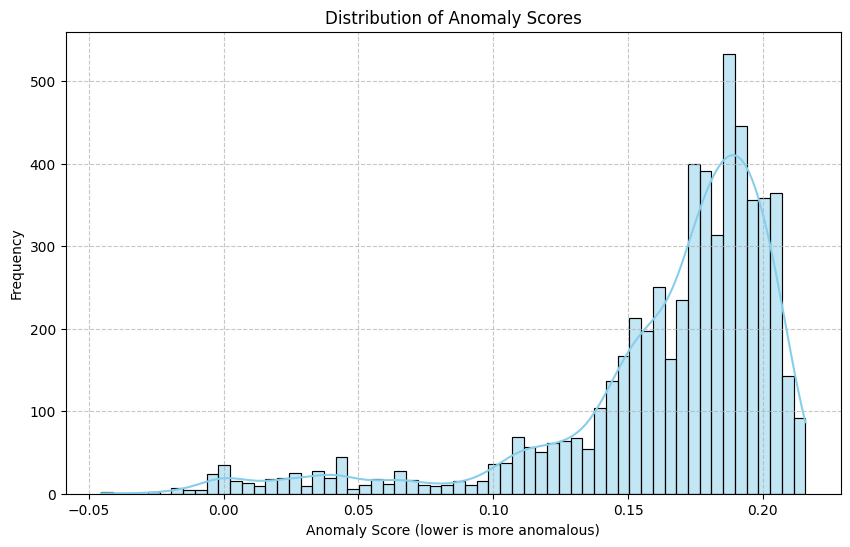

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['score'], kde=True, color='skyblue')
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score (lower is more anomalous)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

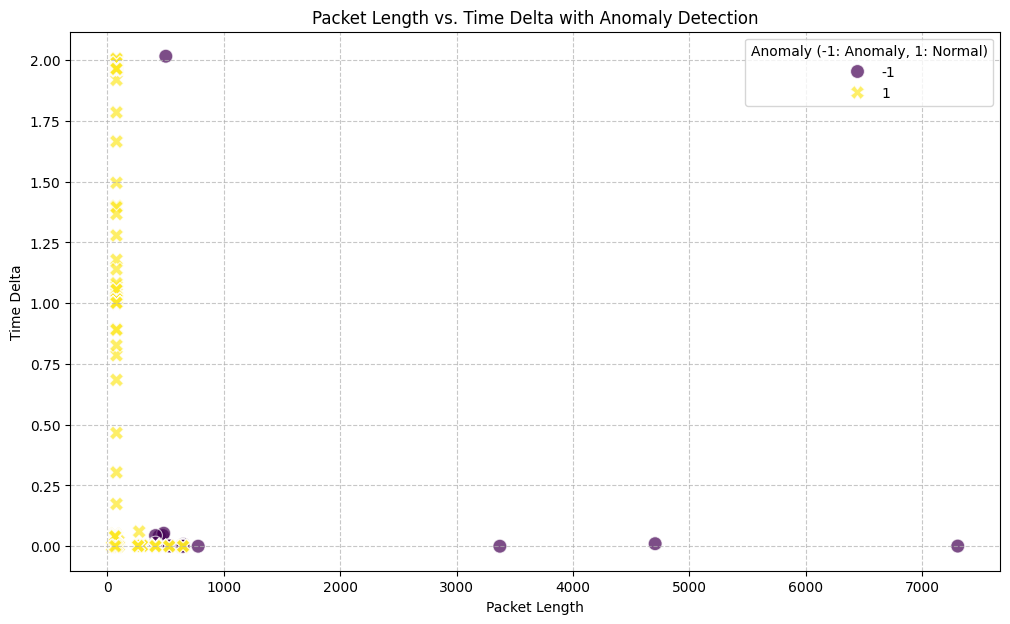

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='pkt_len', y='time_delta', hue='anomaly', style='anomaly', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Packet Length vs. Time Delta with Anomaly Detection')
plt.xlabel('Packet Length')
plt.ylabel('Time Delta')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Anomaly (-1: Anomaly, 1: Normal)')
plt.show()

In [13]:
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(label_encoder_src, 'src_encoder.joblib')
joblib.dump(label_encoder_dst, 'dst_encoder.joblib')

['dst_encoder.joblib']